# pyCrossTalkeR Example - LIANA+ Integration
## Comparative Cell-Cell Communication with LIANA+ and CrossTalkeR
### Background

[CrossTalkeR](https://academic.oup.com/bioinformatics/article/37/22/4263/6275746) ([Nagai et al., 2021](https://academic.oup.com/bioinformatics/article/37/22/4263/6275746)) represents cell-cell communication as a directed graph: nodes are cell types and edges are the ligand-receptor signals sent between them. By scoring each node's importance in this graph (e.g. via PageRank) and **comparing those scores between two conditions**, it highlights the cell types whose communication patterns change the most — i.e. the candidate condition-driving cell types and their ligand-receptor interactions.

`pyCrossTalkeR` is the Python implementation of CrossTalkeR. In addition to the graph rankings, it tests which interactions differ significantly between conditions using two complementary features: the **number** of interactions (proportion / Fisher test) and their **strength** (expression / Mann-Whitney test).

In this notebook we take ligand-receptor scores inferred per condition with `liana`, hand them to `pyCrossTalkeR`, and walk through the comparative graph, ranking, and statistical views to read out how IFN-β stimulation reshapes PBMC communication.

### Load Packages

In [ ]:
pip install pycrosstalker

In [6]:
import pandas as pd
import scanpy as sc
import plotnine as p9
import liana as li
import warnings
warnings.filterwarnings('ignore')
from collections import defaultdict
from pycrosstalker import tools as cttl
from pycrosstalker import plots as ctpl
%matplotlib inline
from scipy.stats import gmean
import os
sc.logging.print_header()

Package,Version
pandas,2.2.2
scanpy,1.12
plotnine,0.15.0
liana,1.7.3
pycrosstalker,2.1.6
scipy,1.18.0
Component,Info
Python,"3.12.13 | packaged by conda-forge | (main, Mar 5 2026, 16:50:00) [GCC 14.3.0]"
OS,Linux-4.18.0-513.5.1.el8_9.x86_64-x86_64-with-glibc2.28
CPU,"128/128 logical CPU cores, x86_64"


### Load & Prep Data 

 As a simple example, we will look at ~25k PBMCs from 8 pooled patient lupus samples, each before and after IFN-beta stimulation ([Kang et al., 2018](https://www.nature.com/articles/nbt.4042); [GSE96583](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE96583)). Note that by focusing on PBMCs, for the purpose of this tutorial, we assume that coordinated events occur among them.

This dataset is downloaded from a link on Figshare; preprocessed for [pertpy](https://github.com/theislab/pertpy).

In [2]:
# load data as from CCC chapter
adata = li.testing.datasets.kang_2018()

#### Showcase anndata object

In [3]:
adata.obs.head()

,nCount_RNA,nFeature_RNA,tsne1,tsne2,condition,cluster,cell_type,patient,nCount_SCT,nFeature_SCT,integrated_snn_res.0.4,seurat_clusters,sample,cell_abbr
index,,,,,,,,,,,,,,
AAACATACATTTCC-1,3017.0,877,-27.640373,14.966629,ctrl,9,CD14+ Monocytes,patient_1016,1704.0,711,1,1,ctrl&1016,CD14
AAACATACCAGAAA-1,2481.0,713,-27.493646,28.924885,ctrl,9,CD14+ Monocytes,patient_1256,1614.0,662,1,1,ctrl&1256,CD14
AAACATACCATGCA-1,703.0,337,-10.468194,-5.984389,ctrl,3,CD4 T cells,patient_1488,908.0,337,6,6,ctrl&1488,CD4T
AAACATACCTCGCT-1,3420.0,850,-24.367997,20.429285,ctrl,9,CD14+ Monocytes,patient_1256,1738.0,653,1,1,ctrl&1256,CD14
AAACATACCTGGTA-1,3158.0,1111,27.952170,24.159738,ctrl,4,Dendritic cells,patient_1039,1857.0,928,12,12,ctrl&1039,DCs


In [4]:
adata.obs["cell_type"].cat.categories

Index(['CD4 T cells', 'CD14+ Monocytes', 'B cells', 'NK cells', 'CD8 T cells',
       'FCGR3A+ Monocytes', 'Dendritic cells', 'Megakaryocytes'],
      dtype='object')

In [5]:
sample_key = 'sample'
condition_key = 'condition'
groupby = 'cell_type'

##### Basic QC

Note that this data has been largely pre-processed & annotated, we refer the user to the [Quality Control](https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html) and other relevant chapters from the best-practices book for information about pre-processing and annotation steps.

In [6]:
# filter cells and genes
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
# log1p normalize the data
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In addition to the basic QC steps, one needs to ensure that the cell groups on which they run the analysis are well defined, and stable across samples.

##### Show pre-computed UMAP

In [7]:
adata

AnnData object with n_obs × n_vars = 24562 × 15701
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'condition', 'cluster', 'cell_type', 'patient', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters', 'sample', 'cell_abbr', 'n_genes'
    var: 'name', 'n_cells'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'

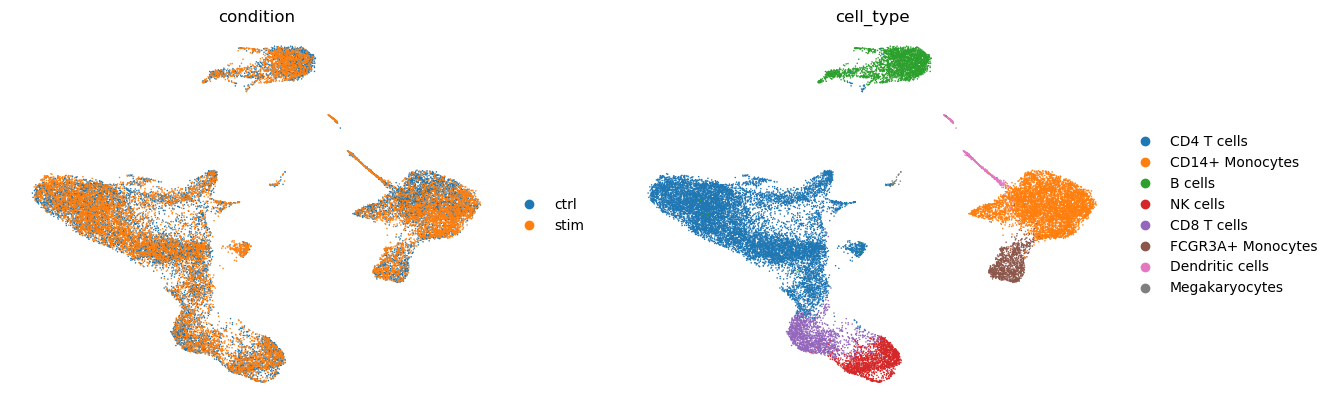

In [10]:
sc.pl.umap(adata, color=[condition_key, groupby], frameon=False)

### Ligand-Receptor Inference by Sample

To compare the effects of stimulation on cell-cell communication, we will first perform ligand-receptor inference using the methods implemented in the `liana` framework, as example of `scseqcomm`.

In [ ]:
li.mt.scseqcomm.by_sample(
    adata,
    groupby=groupby,
    resource_name='consensus', # NOTE: uses human gene symbols!
    sample_key=condition_key, # sample key by which we which to loop
    use_raw=False, 
    verbose=True, # use 'full' to show all verbose information
    n_perms=10, # exclude permutations for speed
    return_all_lrs=False# return all LR values
    )

Check results

In total, we obtained 1892 interactions for the control samples and 1987 for stimulated interactions. Now, we use `CrossTalkeR` for performing a graph-based differential cell-cell communication analysis

In [32]:
adata.uns["liana_res"]

,condition,ligand,ligand_cdf,ligand_complex,ligand_means,ligand_props,receptor,receptor_cdf,receptor_complex,receptor_means,receptor_props,source,target,inter_score
0,ctrl,HMGB1,1.000000,HMGB1,0.367668,0.709302,CXCR4,1.000000,CXCR4,0.389708,0.900000,Dendritic cells,Megakaryocytes,1.000000
1,ctrl,HMGB1,1.000000,HMGB1,0.283185,0.468100,CXCR4,1.000000,CXCR4,0.965636,0.764748,CD14+ Monocytes,CD4 T cells,1.000000
2,ctrl,PKM,1.000000,PKM,0.821950,0.834869,CD44,1.000000,CD44,0.447393,0.484712,CD14+ Monocytes,CD4 T cells,1.000000
3,ctrl,VIM,1.000000,VIM,1.519413,0.969294,CD44,1.000000,CD44,0.447393,0.484712,CD14+ Monocytes,CD4 T cells,1.000000
4,ctrl,MMP9,1.000000,MMP9,0.060708,0.103719,CD44,1.000000,CD44,0.447393,0.484712,CD14+ Monocytes,CD4 T cells,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3874,stim,SIRPA,0.327294,SIRPA,0.031316,0.110701,CD47,1.000000,CD47,0.213795,0.272807,Dendritic cells,CD4 T cells,0.327294
3875,stim,CD47,1.000000,CD47,0.274689,0.293844,SIRPA,0.327294,SIRPA,0.031316,0.110701,NK cells,Dendritic cells,0.327294
3876,stim,SIRPA,0.327294,SIRPA,0.031316,0.110701,CD47,1.000000,CD47,0.408296,0.483146,Dendritic cells,B cells,0.327294
3877,stim,SIRPA,0.327294,SIRPA,0.031316,0.110701,CD47,1.000000,CD47,0.501579,0.755712,Dendritic cells,FCGR3A+ Monocytes,0.327294


In [33]:
adata = cttl.utils.from_liana(adata,
                              liana_key = "liana_res",
                              compute_means=True,pval_filter=False)
adata = cttl.analise_LR(adata,save=False)

Create a Differential Table
Calculating CCI Ranking
Calculating GCI Ranking
Network Analysis Done
Generating h5ad file with Analysed Results


We visualize the main differences with `plot_cci`, which draws the **comparative** communication graph (stimulated vs. control):

- **Nodes** are cell types, coloured by cell type. Node **size** encodes the *magnitude* of each cell type's change in PageRank importance between conditions — larger nodes changed the most.
- **Edges** are the differential signalling between cell types: **red** edges are stronger under stimulation, **blue** edges stronger under control; edge **width** scales with the size of the difference.

We pass the absolute differential PageRank as the node size (`.abs()`), since size reflects *how much* a cell type's role changed; the *direction* of change is read from the edge colours and from the ranking bar plot further down.

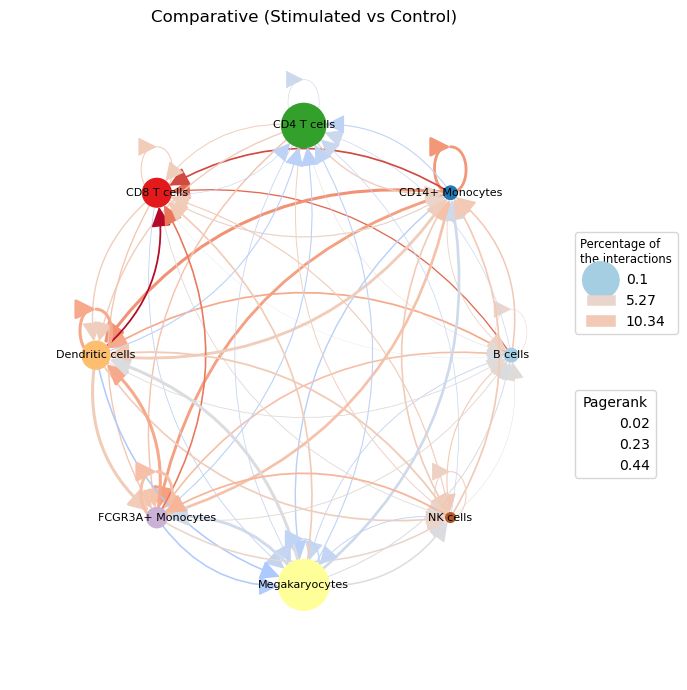

In [34]:
ctpl.plot.plot_cci(graph=adata.uns['pycrosstalker']['results']["graphs"]["stim_x_ctrl"],
        colors=adata.uns['pycrosstalker']['results']["colors"],
        plt_name='Comparative (Stimulated vs Control)',
        coords=adata.uns['pycrosstalker']['results']["coords"],
        emax= None,
        leg= False,
        low= 0,
        high= 0,
        ignore_alpha= False,
        log= False,
        efactor= 2,
        vfactor= 12,
        # node size = magnitude of the differential PageRank (signed -> abs),
        # otherwise cell types that drop in importance get a negative size and vanish
        pg= adata.uns['pycrosstalker']['results']["rankings"]["stim_x_ctrl"]["Pagerank"].abs(),
        figsize= (7, 7),
        scale_factor= 2.0,
        node_size=3.0,
        font_size=8,
        )

Beyond the graph view, `pyCrossTalkeR` tests which cell-cell pairs change significantly between conditions. The first test compares the **number of interactions** (the count of LR pairs) per cell-type pair using a Fisher/proportion test. The volcano plot below shows the fold-change vs. significance, highlighting pairs that gain or lose interactions under stimulation.

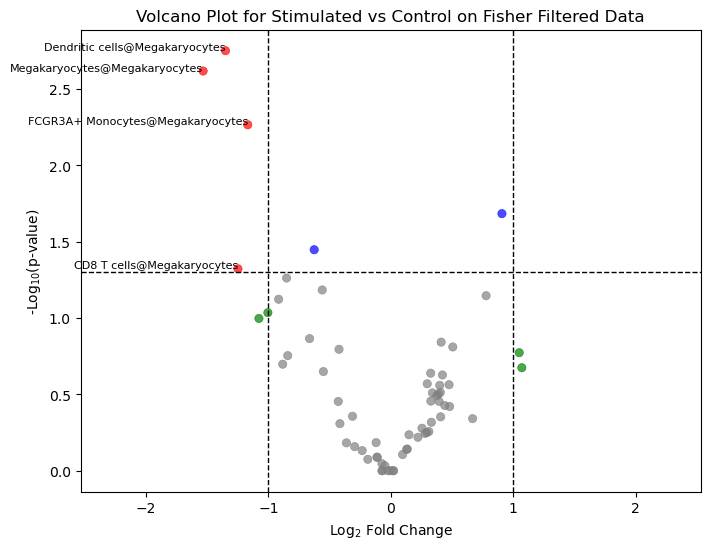

In [35]:
ctpl.plot_volcane(adata.uns['pycrosstalker']['results']['stats']['stim_x_ctrl'], 
                  "fisher", 
                  p_threshold=0.05, 
                  fc_threshold=1, annot=True, title="Volcano Plot for Stimulated vs Control on Fisher Filtered Data")


From the proportion test we see an increase in interactions from B cells to Dendritic cells under stimulation — consistent with the IFN-β response also highlighted in the [liana-cell2cell notebook](https://liana-py.readthedocs.io/en/latest/notebooks/liana_c2c.html). Restricting the comparative graph to these significantly-changed pairs (the *Fisher-filtered* graph) gives a cleaner view of where communication is rewired:

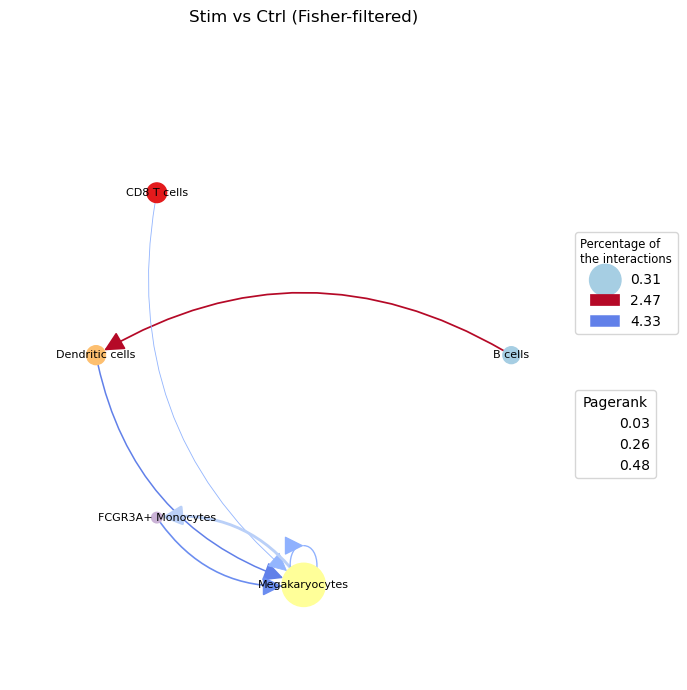

In [36]:
ctpl.plot.plot_cci(graph=adata.uns['pycrosstalker']['results']["graphs"]["stim_x_ctrl_filtered"],
        colors=adata.uns['pycrosstalker']['results']["colors"],
        plt_name='Stim vs Ctrl (Fisher-filtered)',
        coords=adata.uns['pycrosstalker']['results']["coords"],
        emax= None,
        leg= False,
        low= 0,
        high= 0,
        ignore_alpha= False,
        log= False,
        efactor= 2,
        vfactor= 12,
        # node size = magnitude of the differential PageRank (signed -> abs)
        pg= adata.uns['pycrosstalker']['results']["rankings"]["stim_x_ctrl_filtered"]["Pagerank"].abs(),
        figsize= (7, 7),
        scale_factor= 2.0,
        node_size=2.0,
        font_size=8,
        )

The second test complements this by comparing the **strength of interactions** (the LR scores) rather than their count, using a Mann-Whitney U test. This volcano plot flags cell-type pairs whose signalling intensity — not just the number of active LR pairs — shifts between conditions.

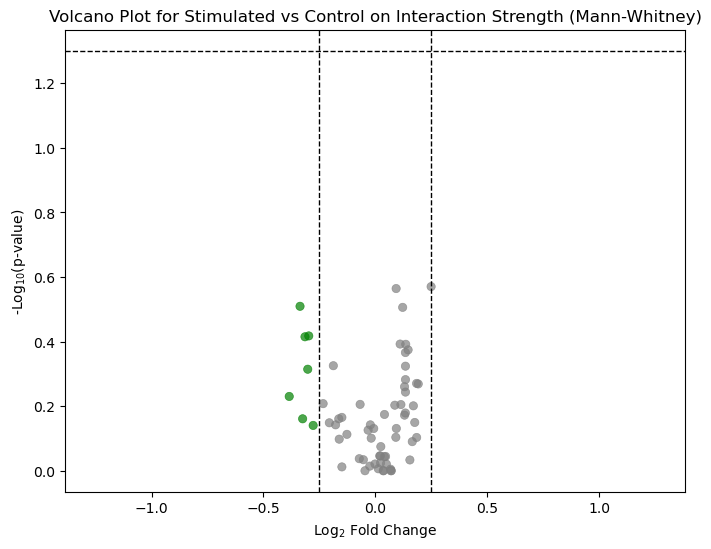

In [37]:
ctpl.plot_volcane(adata.uns['pycrosstalker']['results']['stats']['stim_x_ctrl:MannU'], 
                  "mannwhitneyu", 
                  p_threshold=0.05, 
                  fc_threshold=0.25, annot=True, title="Volcano Plot for Stimulated vs Control on Interaction Strength (Mann-Whitney)")


The bar plot ranks cell types by their **differential PageRank**: positive values gain communication importance under stimulation, negative values lose it. This is the signed quantity whose magnitude sized the nodes in the graph above.

The clustermap shows the same Fisher-filtered differential graph as a sender × receiver matrix, clustering cell types by their changed signalling so that coordinated shifts (e.g. shared senders or receivers) become apparent.

Finally, the Sankey plot zooms into a single sender→receiver pair (here B cells → Dendritic cells) and breaks the change down to the level of individual ligand-receptor pairs, showing which interactions drive the differential signal between conditions.

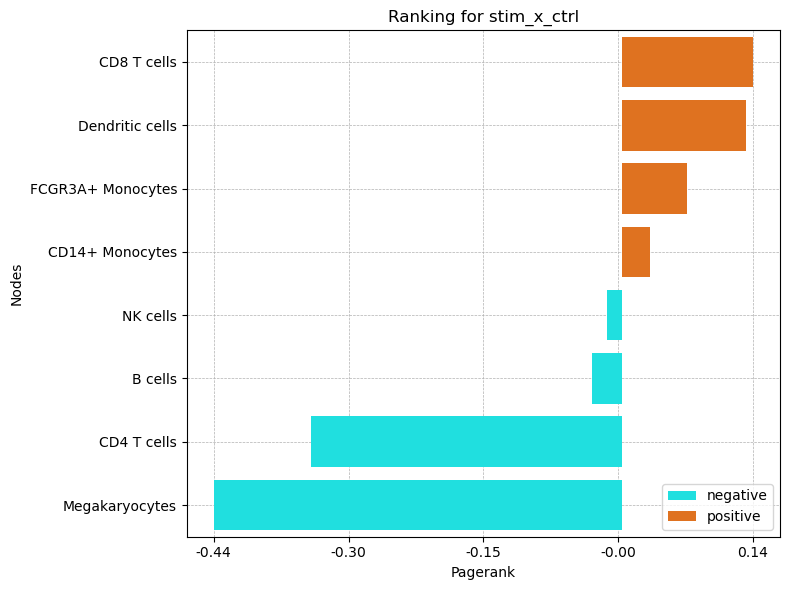

In [38]:
ctpl.plot_bar_rankings(adata, "stim_x_ctrl", "Pagerank")

This notebook covered the core comparative workflow: per-condition LR inference with `liana`, graph construction and ranking with `pyCrossTalkeR`, and reading out condition-driving cell types and interactions. The full range of downstream analyses — including cell-gene (CGI) networks and PCA of the rankings — is documented in the [pyCrossTalkeR tutorial](https://github.com/CostaLab/pyCrossTalkeR).

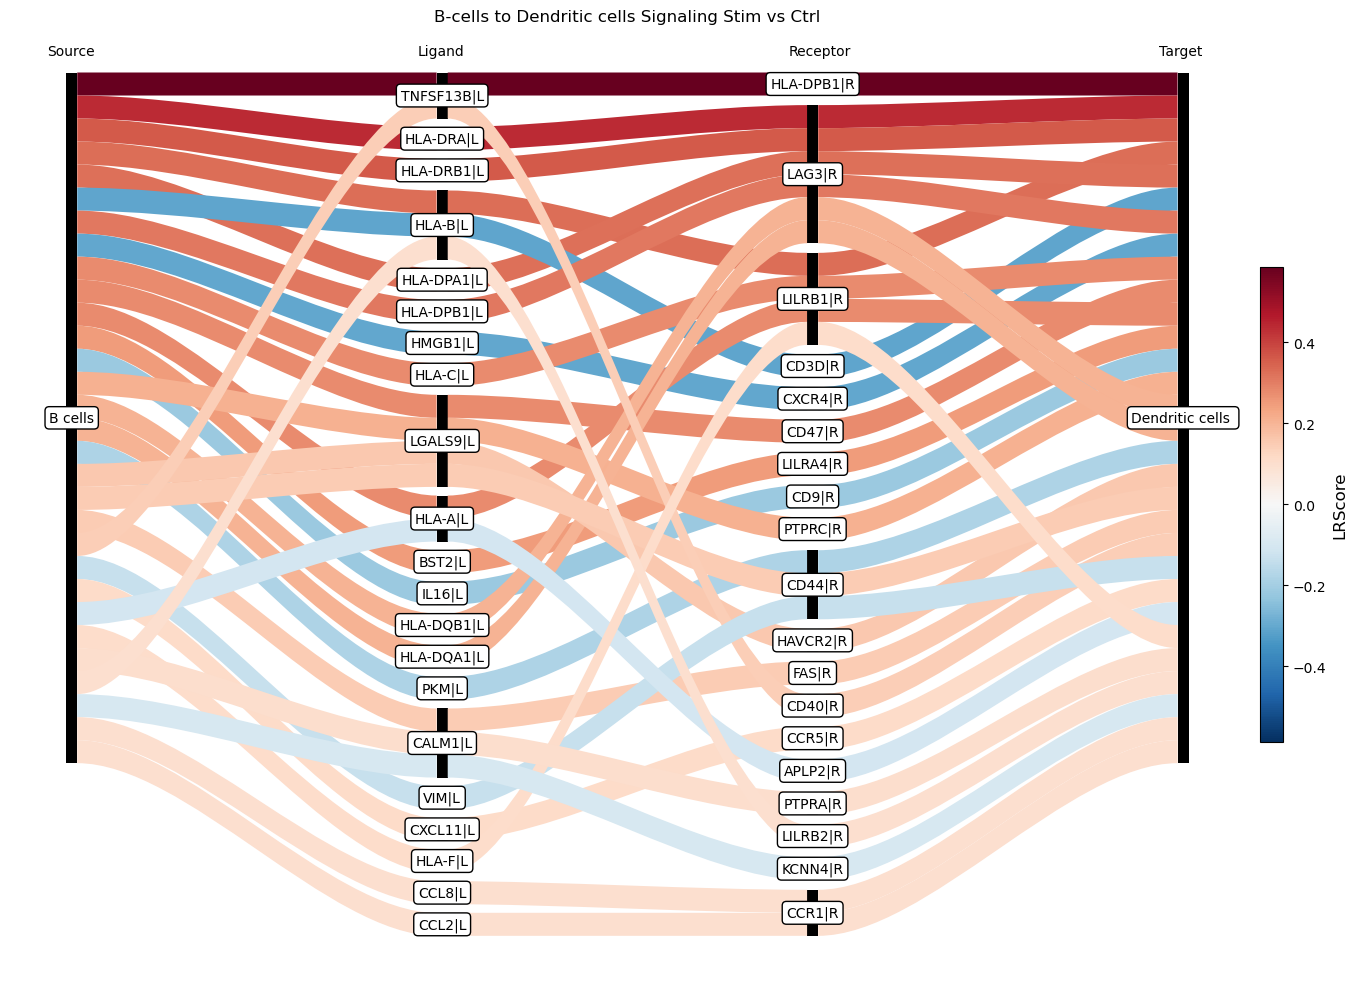

In [39]:
ctpl.plot_sankey(
    adata.uns['pycrosstalker']['results']['tables']['stim_x_ctrl'],
    ligand_cluster = ["B cells"],
    receptor_cluster = ["Dendritic cells"],
    plt_name = "B-cells to Dendritic cells Signaling Stim vs Ctrl",
    threshold = 30)

### Outlook & Further Analysis

There are different ways to explore these results downstream of the pyCrossTalker, these can be further performed using pyCrossTalkeR Tutorial.